In [31]:
import pandas as pd
DATA_PATH = "/home/jovyan/work/ner_congressional_records/DATA/"


In [32]:
print(1)

1


In [33]:
train = pd.read_csv(DATA_PATH+"train.csv")
test = pd.read_csv(DATA_PATH+"test.csv")

In [34]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# preprocessing
# Features and target
X_train = train['full_name'] # name
y_train = train['label'] # label
X_test = test['full_name']
y_test = test['label']

# Convert names to numeric features
vectorizer = TfidfVectorizer(stop_words='english', max_features=1000)
X_tfidf = vectorizer.fit_transform(X_train.fillna(''))  # Handle NaN
X_test_tfidf = vectorizer.transform(X_test.fillna(''))


# Train model
model = LogisticRegression(max_iter=1000)
model.fit(X_tfidf, y_train)


LogisticRegression(max_iter=1000)

In [35]:
# Predict
predictions = model.predict(X_test_tfidf)

In [36]:
# scores
# Evaluate
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.98      0.70      0.82     19155
           1       0.77      0.98      0.86     19160

    accuracy                           0.84     38315
   macro avg       0.87      0.84      0.84     38315
weighted avg       0.87      0.84      0.84     38315



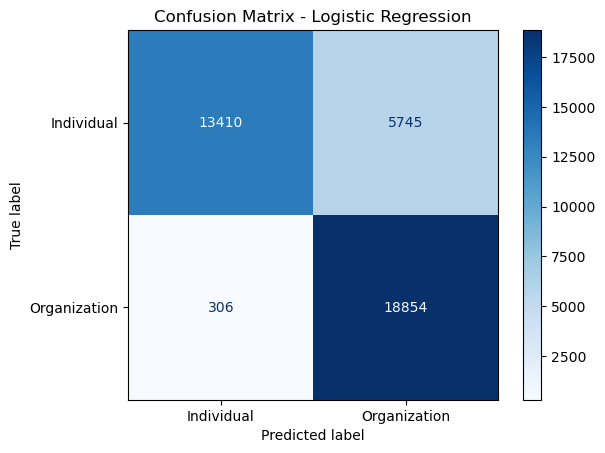

In [37]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

#Confusion matrix
cm = confusion_matrix(y_test, predictions, labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Individual', 'Organization'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Logistic Regression")
plt.show()